In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple

import pandas as pd
from pycocotools.coco import COCO
from tqdm.auto import tqdm

# Project-relative roots (robustly find repo root when running this notebook from any subdir)

def find_repo_root(start: Optional[Path] = None) -> Path:
    start = start or Path.cwd()
    current = start.resolve()
    for _ in range(8):
        if (current / "data").exists() and (current / "work_dirs").exists():
            return current
        if (current.parent == current):
            break
        current = current.parent
    # Fallback: assume notebook is inside repo at no_time_to_train/make_plots/
    # repo_root = <notebook_dir>/../../
    return (Path.cwd() / "../../").resolve()

REPO_ROOT = find_repo_root()
PER_CLASS_DIR = REPO_ROOT / "data/coco/annotations/per_class_instances"
ABLATION_WORK_DIR = REPO_ROOT / "work_dirs/1shot_ref_ablation"

# Few-shot COCO classes
from no_time_to_train.dataset.metainfo import METAINFO
COCO_CLASSES: List[str] = list(METAINFO["few_shot_classes"])  # ensure list copy


def parse_ref_selection_csv(class_name: str) -> pd.DataFrame:
    """
    Read the per-class reference selection CSV into a DataFrame with columns:
      ['ann_id', 'area_cat', 'centered', 'avoid_sides']
    Expected CSV at:
      data/coco/annotations/per_class_instances/<class>/instances/ref_image_selections.csv
    """
    csv_path = PER_CLASS_DIR / class_name / "instances" / "ref_image_selections.csv"
    if not csv_path.exists():
        return pd.DataFrame(columns=["ann_id", "area_cat", "centered", "avoid_sides"]).astype(
            {"ann_id": "Int64", "area_cat": "string", "centered": "boolean", "avoid_sides": "Int64"}
        )

    df = pd.read_csv(csv_path)
    # Normalize & rename columns
    rename_map = {
        "id": "ann_id",
        "area": "area_cat",
    }
    df = df.rename(columns=rename_map)

    # Types and cleaning
    if "ann_id" in df.columns:
        df["ann_id"] = pd.to_numeric(df["ann_id"], errors="coerce").astype("Int64")
    else:
        df["ann_id"] = pd.Series(dtype="Int64")

    # area_cat as string category-like
    if "area_cat" in df.columns:
        df["area_cat"] = df["area_cat"].astype("string").str.lower()
    else:
        df["area_cat"] = pd.Series(dtype="string")

    # centered to boolean
    if "centered" in df.columns:
        df["centered"] = (
            df["centered"].astype("string").str.strip().str.lower().map({"true": True, "false": False})
        ).astype("boolean")
    else:
        df["centered"] = pd.Series(dtype="boolean")

    # avoid_sides to Int64
    if "avoid_sides" in df.columns:
        df["avoid_sides"] = pd.to_numeric(df["avoid_sides"], errors="coerce").astype("Int64")
    else:
        df["avoid_sides"] = pd.Series(dtype="Int64")

    # Append class name
    df["class"] = class_name

    # Keep only expected cols in final order
    keep_cols = ["class", "ann_id", "area_cat", "centered", "avoid_sides"]
    return df[keep_cols]


def parse_scores_for_ref(class_name: str, ann_id: int) -> Tuple[Optional[float], Optional[float]]:
    """
    Parse BBOX and SEGM AP IoU=0.50:0.95 from:
      work_dirs/1shot_ref_ablation/<class>_<ann_id>/coco_eval_stats_.txt
    Returns (bbox_ap_iou, segm_ap_iou) or (None, None) if missing.
    """
    exp_dir = ABLATION_WORK_DIR / f"{class_name}_{ann_id}"
    stats_path = exp_dir / "coco_eval_stats_.txt"
    if not stats_path.exists():
        print(f"Missing stats for {class_name} {ann_id}")
        return None, None

    bbox_ap = None
    segm_ap = None
    section = None
    try:
        with stats_path.open("r", encoding="utf-8") as f:
            for line in f:
                s = line.strip()
                if s.startswith("===== BBOX RESULTS ====="):
                    section = "bbox"
                    continue
                if s.startswith("===== SEGM RESULTS ====="):
                    section = "segm"
                    continue
                if section in {"bbox", "segm"} and s.startswith("AP IoU=0.50:0.95:"):
                    # Line format: "AP IoU=0.50:0.95: 0.0301"
                    try:
                        value_str = s.split(":", maxsplit=2)[-1].strip()
                        value = float(value_str)
                    except Exception:
                        raise ValueError(f"Failed to parse {value_str} as float")
                        value = None
                    if section == "bbox":
                        bbox_ap = value
                    else:
                        segm_ap = value
                    # Do not break; keep scanning in case multiple sections appear out of order
    except Exception:
        raise Exception("Failed to parse scores for ref")
        return None, None

    return bbox_ap, segm_ap


def load_coco_for_class(class_name: str) -> Optional[COCO]:
    ann_path = PER_CLASS_DIR / class_name / "instances_train2017.json"
    if not ann_path.exists():
        return None
    try:
        return COCO(str(ann_path))
    except Exception:
        raise Exception("Failed to load COCO for class")
        return None


def compute_ann_features(coco: COCO, ann_id: int) -> Optional[Dict[str, float]]:
    """
    Derive features from COCO for the given annotation id:
      - abs_area_px: ann['area'] (segmentation area in pixels)
      - norm_area_px: abs_area_px / (img_w * img_h)
      - norm_bbox_x, norm_bbox_y: bbox center normalized to [0,1]
      - min_dist_to_edge_px: min distance from bbox to image edges (in px)
    Returns None if annotation or image not found.
    """
    anns = coco.loadAnns([int(ann_id)])
    if not anns:
        return None
    ann = anns[0]

    img_id = ann.get("image_id")
    if img_id is None:
        return None
    imgs = coco.loadImgs([int(img_id)])
    if not imgs:
        return None
    img = imgs[0]

    img_w = float(img.get("width", 0) or 0)
    img_h = float(img.get("height", 0) or 0)
    if img_w <= 0 or img_h <= 0:
        return None

    # Areas
    abs_area_px = float(ann.get("area", 0.0) or 0.0)
    norm_area_px = abs_area_px / (img_w * img_h) if img_w * img_h > 0 else 0.0

    # BBox-derived features
    bbox = ann.get("bbox") or [0.0, 0.0, 0.0, 0.0]
    x, y, w, h = map(float, bbox)
    cx = x + w / 2.0
    cy = y + h / 2.0
    norm_bbox_x = cx / img_w
    norm_bbox_y = cy / img_h

    # Distances to frame edges (px)
    left = max(0.0, x)
    top = max(0.0, y)
    right = max(0.0, img_w - (x + w))
    bottom = max(0.0, img_h - (y + h))
    min_dist_to_edge_px = min(left, top, right, bottom)

    return {
        "abs_area_px": abs_area_px,
        "norm_area_px": norm_area_px,
        "norm_bbox_x": norm_bbox_x,
        "norm_bbox_y": norm_bbox_y,
        "min_dist_to_edge_px": min_dist_to_edge_px,
    }


# Build consolidated dataset
all_rows: List[Dict] = []

classes_to_process = [c for c in COCO_CLASSES if (PER_CLASS_DIR / c).exists()]
print(f"Found {len(classes_to_process)} COCO few-shot classes with per-class data.")

for class_name in tqdm(classes_to_process, desc="Classes"):
    # Load selections
    sel_df = parse_ref_selection_csv(class_name)
    if sel_df.empty:
        continue

    # Load COCO for this class once
    coco = load_coco_for_class(class_name)

    for _, row in sel_df.iterrows():
        ann_id = int(row["ann_id"]) if pd.notna(row["ann_id"]) else None
        if ann_id is None:
            continue

        bbox_ap, segm_ap = parse_scores_for_ref(class_name, ann_id)

        features: Dict[str, Optional[float]] = {
            "class": class_name,
            "ann_id": ann_id,
            "area_cat": (row["area_cat"] if pd.notna(row["area_cat"]) else None),
            "centered": (bool(row["centered"]) if pd.notna(row["centered"]) else None),
            "avoid_sides": (int(row["avoid_sides"]) if pd.notna(row["avoid_sides"]) else None),
            "bbox_ap_iou": bbox_ap,
            "segm_ap_iou": segm_ap,
        }

        if coco is not None:
            ann_feats = compute_ann_features(coco, ann_id)
        else:
            ann_feats = None

        if ann_feats is not None:
            features.update(ann_feats)
        else:
            print(f"Failed to compute features for {class_name} {ann_id}")
            features.update({
                "abs_area_px": None,
                "norm_area_px": None,
                "norm_bbox_x": None,
                "norm_bbox_y": None,
                "min_dist_to_edge_px": None,
            })

        all_rows.append(features)

# Create DataFrame with specified column order
columns = [
    "class",
    "ann_id",
    "area_cat",
    "centered",
    "avoid_sides",
    "bbox_ap_iou",
    "segm_ap_iou",
    "abs_area_px",
    "norm_area_px",
    "norm_bbox_x",
    "norm_bbox_y",
    "min_dist_to_edge_px",
]

dataset_df = pd.DataFrame(all_rows, columns=columns)

# Save and preview
out_dir = ABLATION_WORK_DIR / "analysis"
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "1shot_ref_dataset.csv"
dataset_df.to_csv(out_csv, index=False)

print(f"Rows: {len(dataset_df)} | Saved to: {out_csv}")
dataset_df.head(10)


Found 18 COCO few-shot classes with per-class data.


Classes:   0%|          | 0/18 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=6.17s)
creating index...
index created!
Missing stats for person 223995
Missing stats for person 2150138
Missing stats for person 2032133
Missing stats for person 2030629
Missing stats for person 2206849
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Missing stats for bicycle 344110
Missing stats for bicycle 241833
Missing stats for bicycle 241374
Missing stats for bicycle 344087
Missing stats for bicycle 241639
Missing stats for bicycle 129371
Missing stats for bicycle 2035096
Missing stats for bicycle 241492
Missing stats for bicycle 2168289
Missing stats for bicycle 127582
Missing stats for bicycle 2168713
Missing stats for bicycle 126244
Missing stats for bicycle 2168353
Missing stats for bicycle 242009
Missing stats for bicycle 2168291
Missing stats for bicycle 2167956
Missing stats for bicycle 2035202
Missing stats for bicycle 2035726
Missing stats for bicycle 241487
Missing stats for bicycle 2036098
M

,class,ann_id,area_cat,centered,avoid_sides,bbox_ap_iou,segm_ap_iou,abs_area_px,norm_area_px,norm_bbox_x,norm_bbox_y,min_dist_to_edge_px
0,person,1708499,large,True,100,0.3077,0.2935,69669.25345,0.170091,0.516852,0.562922,104.99
1,person,1723071,large,True,100,0.4088,0.3965,65333.59500,0.159506,0.562492,0.499164,101.25
2,person,1715103,large,True,100,0.2977,0.2938,63169.54500,0.205630,0.500625,0.474070,101.00
3,person,457000,large,True,100,0.2946,0.2802,58646.49420,0.146851,0.493486,0.507734,102.41
4,person,2162873,large,True,100,0.3990,0.3706,58350.41020,0.164869,0.475217,0.409328,102.80
5,person,2156725,large,True,100,0.3392,0.3106,57796.95115,0.141106,0.501344,0.509461,111.19
6,person,1683276,large,True,100,0.1027,0.0968,56491.72305,0.183892,0.545740,0.573547,102.44
7,person,506813,large,True,100,0.3808,0.3484,56210.89760,0.174265,0.491078,0.464048,103.07
8,person,2162148,large,True,100,0.3940,0.3619,52953.73090,0.172375,0.498188,0.498641,104.21
9,person,475193,large,True,100,0.3191,0.3120,52835.80900,0.137364,0.545672,0.459459,110.32


Filtered rows: 1107 / 1840
loading annotations into memory...
Done (t=5.46s)
creating index...
index created!
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.44s)
creating index...
index created!
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.80s)
creating index...
index created!
loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
loading annotations into memory...
Done (t=0.22s)
creating i

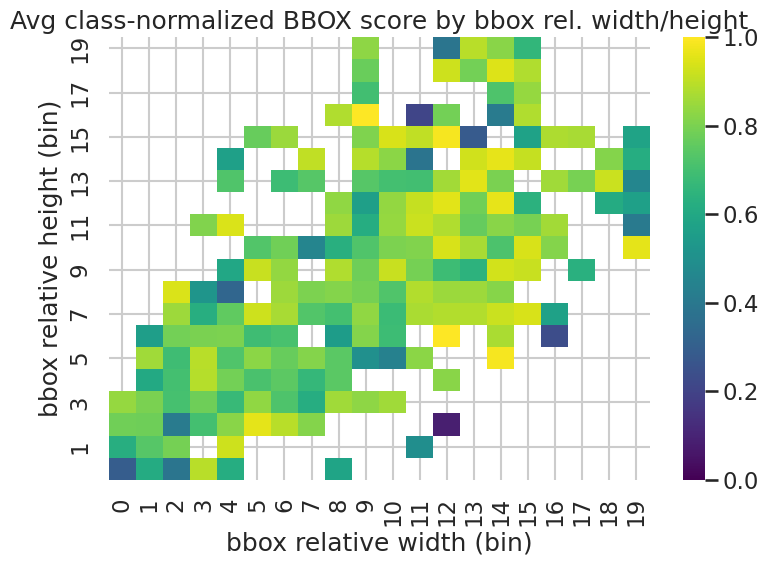

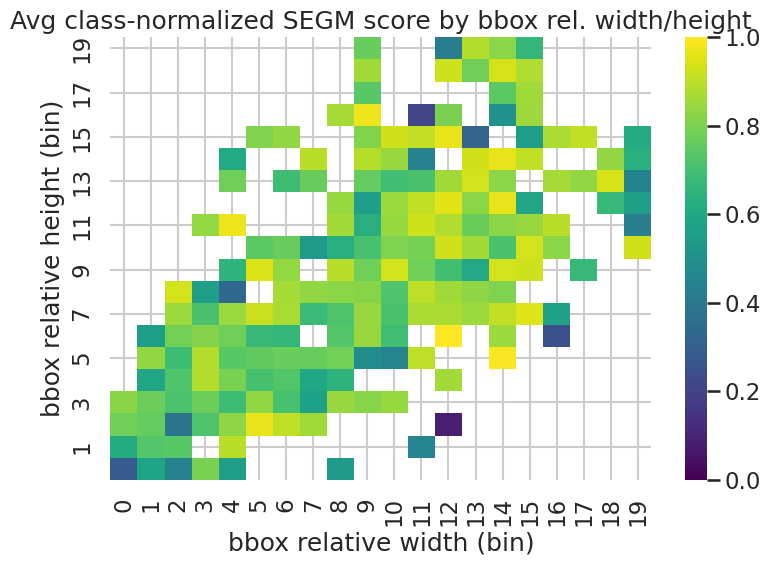

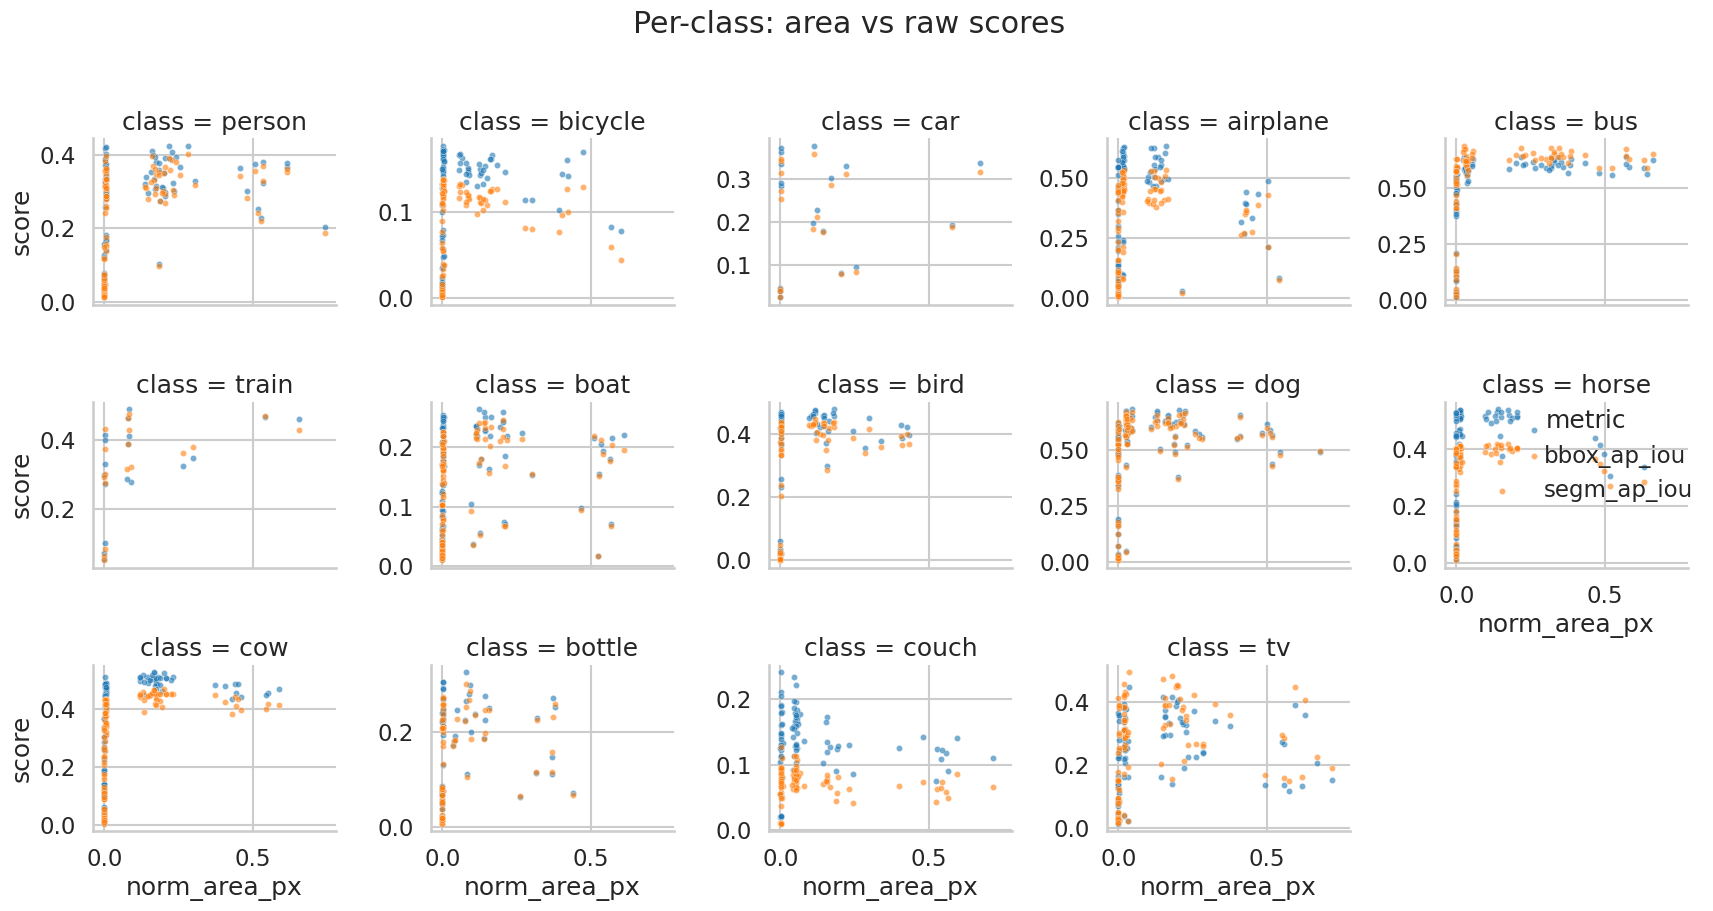

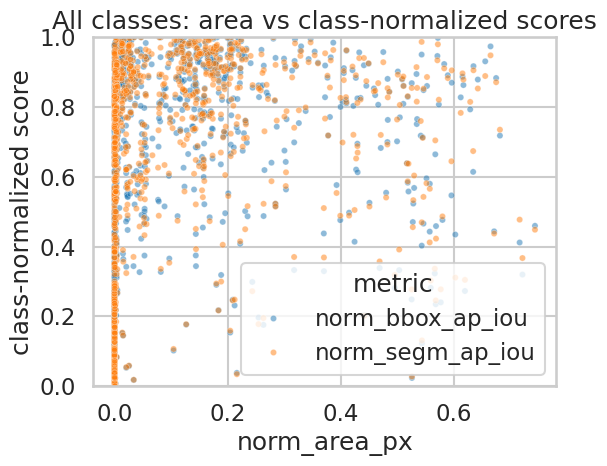

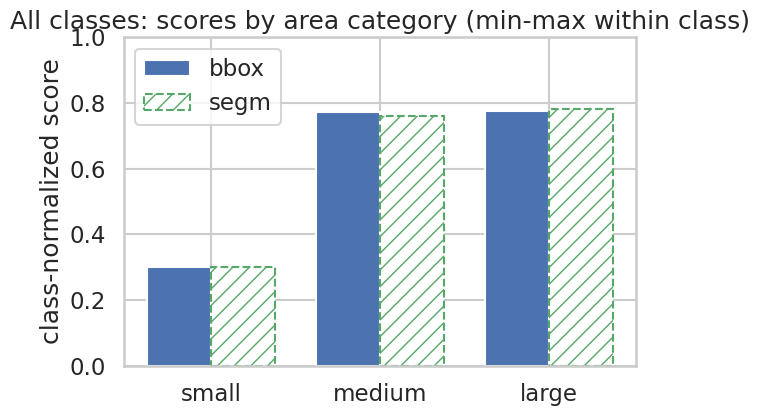

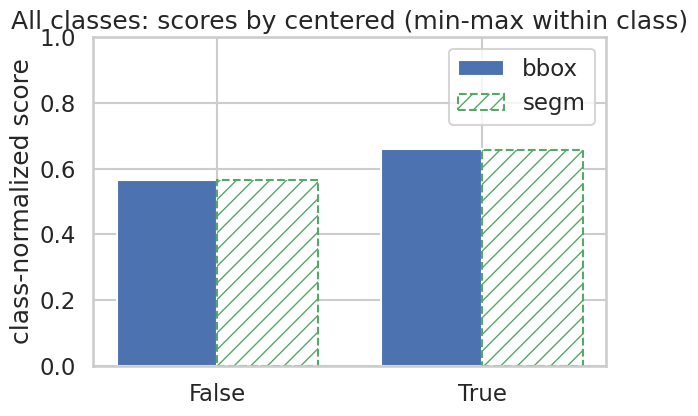

,class,ann_id,area_cat,centered,avoid_sides,bbox_ap_iou,segm_ap_iou,abs_area_px,norm_area_px,norm_bbox_x,norm_bbox_y,min_dist_to_edge_px,norm_bbox_ap_iou,norm_segm_ap_iou,norm_bbox_w,norm_bbox_h
0,person,1708499,large,True,100,0.3077,0.2935,69669.25345,0.170091,0.516852,0.562922,104.99,0.716756,0.722923,0.494391,0.546063
1,person,1723071,large,True,100,0.4088,0.3965,65333.59500,0.159506,0.562492,0.499164,101.25,0.962981,0.987908,0.452609,0.681922
2,person,1715103,large,True,100,0.2977,0.2938,63169.54500,0.205630,0.500625,0.474070,101.00,0.692401,0.723694,0.577917,0.537016
3,person,457000,large,True,100,0.2946,0.2802,58646.49420,0.146851,0.493486,0.507734,102.41,0.684851,0.688706,0.339760,0.664500
4,person,2162873,large,True,100,0.3990,0.3706,58350.41020,0.164869,0.475217,0.409328,102.80,0.939113,0.921276,0.560669,0.497406
5,person,2156725,large,True,100,0.3392,0.3106,57796.95115,0.141106,0.501344,0.509461,111.19,0.793473,0.766915,0.446938,0.633609
6,person,1683276,large,True,100,0.1027,0.0968,56491.72305,0.183892,0.545740,0.573547,102.44,0.217487,0.216877,0.439104,0.532781
7,person,506813,large,True,100,0.3808,0.3484,56210.89760,0.174265,0.491078,0.464048,103.07,0.894788,0.864163,0.610531,0.519087
8,person,2162148,large,True,100,0.3940,0.3619,52953.73090,0.172375,0.498188,0.498641,104.21,0.926936,0.898894,0.532292,0.671625
9,person,475193,large,True,100,0.3191,0.3120,52835.80900,0.137364,0.545672,0.459459,110.32,0.744520,0.770517,0.562594,0.551797


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from typing import Tuple, Dict

sns.set_context("talk")
sns.set_style("whitegrid")

# Start from the dataset built in the previous cell
assert 'dataset_df' in globals(), "Run the first cell to construct dataset_df."

# 1) Filter rows with both bbox and segm scores present
processed_df = dataset_df.dropna(subset=["bbox_ap_iou", "segm_ap_iou"]).copy()
print(f"Filtered rows: {len(processed_df)} / {len(dataset_df)}")

# 2) Per-class min-max normalization for bbox and segm scores

def _minmax_series(s: pd.Series) -> pd.Series:
    minv = s.min()
    maxv = s.max()
    if pd.isna(minv) or pd.isna(maxv):
        return pd.Series([np.nan] * len(s), index=s.index)
    rng = maxv - minv
    if rng <= 1e-12:
        # If no variance within class, set neutral 0.5
        return pd.Series([0.5] * len(s), index=s.index)
    return (s - minv) / rng

processed_df["norm_bbox_ap_iou"] = (
    processed_df.groupby("class")["bbox_ap_iou"].transform(_minmax_series)
)
processed_df["norm_segm_ap_iou"] = (
    processed_df.groupby("class")["segm_ap_iou"].transform(_minmax_series)
)

# 3) Compute normalized bbox width/height using COCO (per-class cache)
#    Uses functions and constants defined in previous cell: load_coco_for_class, PER_CLASS_DIR
from pycocotools.coco import COCO

_coco_cache: Dict[str, COCO] = {}

def _get_coco_for_class(class_name: str) -> COCO | None:
    if class_name in _coco_cache:
        return _coco_cache[class_name]
    coco = load_coco_for_class(class_name)
    _coco_cache[class_name] = coco
    return coco


def _compute_wh_norm(row: pd.Series) -> Tuple[float, float]:
    cls = row["class"]
    ann_id = int(row["ann_id"]) if pd.notna(row["ann_id"]) else None
    if ann_id is None:
        return (np.nan, np.nan)
    coco = _get_coco_for_class(cls)
    if coco is None:
        return (np.nan, np.nan)
    anns = coco.loadAnns([ann_id])
    if not anns:
        return (np.nan, np.nan)
    ann = anns[0]
    bbox = ann.get("bbox") or [np.nan, np.nan, np.nan, np.nan]
    if any(pd.isna(bbox)):
        return (np.nan, np.nan)
    x, y, w, h = map(float, bbox)
    imgs = coco.loadImgs([int(ann.get("image_id"))])
    if not imgs:
        return (np.nan, np.nan)
    img = imgs[0]
    iw = float(img.get("width", 0) or 0)
    ih = float(img.get("height", 0) or 0)
    if iw <= 0 or ih <= 0:
        return (np.nan, np.nan)
    return (w / iw, h / ih)

wh = [
    _compute_wh_norm(row)
    for _, row in processed_df.iterrows()
]
processed_df["norm_bbox_w"] = [t[0] for t in wh]
processed_df["norm_bbox_h"] = [t[1] for t in wh]

# Ensure output directory exists (defined in previous cell as out_dir)
assert 'out_dir' in globals(), "out_dir should be defined in the first cell."
out_dir.mkdir(parents=True, exist_ok=True)

# 4) Heatmaps: avg normalized scores over (norm_bbox_w, norm_bbox_h)

def plot_heatmap(df: pd.DataFrame, value_col: str, title: str, filename: str, bins: int = 20):
    d = df[["norm_bbox_w", "norm_bbox_h", value_col]].dropna()
    d = d[(d["norm_bbox_w"] >= 0) & (d["norm_bbox_w"] <= 1) & (d["norm_bbox_h"] >= 0) & (d["norm_bbox_h"] <= 1)]
    if d.empty:
        print(f"No data for heatmap: {value_col}")
        return
    d["w_bin"] = pd.cut(d["norm_bbox_w"], bins=bins, labels=False, include_lowest=True)
    d["h_bin"] = pd.cut(d["norm_bbox_h"], bins=bins, labels=False, include_lowest=True)
    pivot = d.groupby(["h_bin", "w_bin"], observed=True)[value_col].mean().unstack("w_bin")

    plt.figure(figsize=(8, 6))
    # Flip vertically so (0,0) appears bottom-left
    sns.heatmap(pivot.iloc[::-1], vmin=0, vmax=1, cmap="viridis")
    plt.title(title)
    plt.xlabel("bbox relative width (bin)")
    plt.ylabel("bbox relative height (bin)")
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=200)
    plt.show()

plot_heatmap(
    processed_df,
    value_col="norm_bbox_ap_iou",
    title="Avg class-normalized BBOX score by bbox rel. width/height",
    filename="heatmap_bbox_norm_scores.png",
)
plot_heatmap(
    processed_df,
    value_col="norm_segm_ap_iou",
    title="Avg class-normalized SEGM score by bbox rel. width/height",
    filename="heatmap_segm_norm_scores.png",
)

# 5) Per-class scatter grid: norm_area_px vs raw scores (bbox & segm)
raw_long = processed_df.melt(
    id_vars=["class", "norm_area_px"],
    value_vars=["bbox_ap_iou", "segm_ap_iou"],
    var_name="metric",
    value_name="score",
)
if not raw_long.empty:
    g = sns.FacetGrid(raw_long, col="class", col_wrap=5, sharex=True, sharey=False, hue="metric", height=3)
    g.map_dataframe(sns.scatterplot, x="norm_area_px", y="score", alpha=0.6, s=20)
    g.add_legend()
    g.set_axis_labels("norm_area_px", "score")
    try:
        g.figure.suptitle("Per-class: area vs raw scores", y=1.02)
    except Exception:
        pass
    g.figure.tight_layout()
    g.figure.savefig(out_dir / "per_class_area_vs_raw_scores.png", dpi=200)
    plt.show()
else:
    print("No data for per-class scatter grid.")

# 6) Aggregated scatter (all classes): norm_area_px vs class-normalized scores
norm_long = processed_df.melt(
    id_vars=["norm_area_px"],
    value_vars=["norm_bbox_ap_iou", "norm_segm_ap_iou"],
    var_name="metric",
    value_name="score",
)
if not norm_long.empty:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=norm_long, x="norm_area_px", y="score", hue="metric", alpha=0.5, s=20)
    plt.ylim(0, 1)
    plt.xlabel("norm_area_px")
    plt.ylabel("class-normalized score")
    plt.title("All classes: area vs class-normalized scores")
    plt.tight_layout()
    plt.savefig(out_dir / "all_classes_area_vs_norm_scores.png", dpi=200)
    plt.show()
else:
    print("No data for aggregated scatter.")

# 7) Bar charts: area category vs normalized scores
area_order = ["small", "medium", "large"]
agg_area = (
    processed_df.groupby("area_cat")[ ["norm_bbox_ap_iou", "norm_segm_ap_iou"] ].mean()
    .reindex(area_order)
)
agg_area = agg_area.dropna(how="all")
if not agg_area.empty:
    x = np.arange(len(agg_area.index))
    width = 0.38
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.bar(x - width/2, agg_area["norm_bbox_ap_iou"], width, label="bbox", color="#4C72B0")
    ax.bar(
        x + width/2,
        agg_area["norm_segm_ap_iou"],
        width,
        label="segm",
        edgecolor="#55A868",
        facecolor="white",
        hatch="//",
        linestyle="--",
        linewidth=1.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(agg_area.index)
    ax.set_ylim(0, 1)
    ax.set_ylabel("class-normalized score")
    ax.set_title("All classes: scores by area category (min-max within class)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_dir / "bars_area_category_norm_scores.png", dpi=200)
    plt.show()
else:
    print("No data for area category bars.")

# 8) Bar charts: centered (True/False) vs normalized scores
agg_centered = processed_df.groupby("centered")[ ["norm_bbox_ap_iou", "norm_segm_ap_iou"] ].mean()
agg_centered = agg_centered.dropna(how="all")
if not agg_centered.empty:
    idx = list(agg_centered.index)
    x = np.arange(len(idx))
    width = 0.38
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.bar(x - width/2, agg_centered["norm_bbox_ap_iou"], width, label="bbox", color="#4C72B0")
    ax.bar(
        x + width/2,
        agg_centered["norm_segm_ap_iou"],
        width,
        label="segm",
        edgecolor="#55A868",
        facecolor="white",
        hatch="//",
        linestyle="--",
        linewidth=1.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in idx])
    ax.set_ylim(0, 1)
    ax.set_ylabel("class-normalized score")
    ax.set_title("All classes: scores by centered (min-max within class)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_dir / "bars_centered_norm_scores.png", dpi=200)
    plt.show()
else:
    print("No data for centered bars.")

processed_df.head(10)
